# Week 10 Capstone: verified Week 9 returns and GP-UCB

Week 10 provides eight complete Week 9 query/output pairs. This notebook appends them to the 215 verified observations, yielding 223 observations, reviews F1–F8, and generates reproducible Week 10 GP-UCB proposals with complete diagnostics. A repository-wide provenance audit confirms that returned Week 5 and Week 7 query/output pairs are unavailable and are therefore excluded rather than invented.

## Errors found and corrected

1. `/content/week_9_dataset.zip` is absent, and removing/extracting `/content/week_9_dataset` cannot run locally.
2. Google Drive mounting, Drive dataset writes, and the query-output file write are unavailable and outside repository scope.
3. The original valid alignment checks occur only after the missing archive step, so they never execute here.
4. `display()` is used repeatedly without a guaranteed import.
5. EDA creates a separate trend, running-best, histogram, heatmap, and one scatter figure per dimension, producing dozens of fragmented plots.
6. Pearson correlation is presented as dimensional sensitivity despite sparse nonlinear black-box data. Feature plots are retained but correlation claims removed.
7. Targets are manually standardised and `normalize_y=False`; this duplicates behaviour less transparently than GP `normalize_y=True`.
8. Candidate duplicate checking constructs 100,000 Python tuples, then Function 1 is generated once separately and again in the all-function loop.
9. The output is labelled `WEEK 11 QUERY POINTS` inside Week 10, creating an off-by-one reporting error.
10. The summary calls the external dataset confirmed without explaining the unresolved Weeks 5 and 7 gaps.
11. Empty markdown cells, repeated imports, and Drive-specific state are removed.

In [1]:
from pathlib import Path
import math, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
from sklearn.exceptions import ConvergenceWarning
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import ConstantKernel, Matern, WhiteKernel

FUNCTIONS=tuple(range(1,9)); DIMS={1:2,2:2,3:3,4:4,5:4,6:5,7:6,8:8}; KAPPA={i:2. for i in FUNCTIONS}
ROUNDS_Q={1:[[.375440,.950714],[.536429,.835362],[.614168,.334143],[.872626,.321598]],2:[[.375440,.950714],[.978752,.932731],[.000006,.334143],[.197553,.808683]],3:[[.444444,.666666,.333333],[.657452,.998464,.817253],[.670026,.057881,.658241],[.650132,.218327,.110542]],4:[[.555555,.444444,.222222,.111111],[.006280,.281840,.932013,.960202],[.394519,.361122,.256803,.461856],[.715715,.504442,.275065,.552962]],5:[[.224189,.846480,.879484,.878515],[.255841,.841692,.888984,.860260],[.255842,.841692,.888985,.860266],[0.,0.,0.,0.]],6:[[.728186,.154693,.732552,.693997,.564013],[.433654,.486678,.282753,.972905,.323321],[.495070,.097152,.672921,.000007,.351268],[.973181,.022807,.714484,.145453,.974790]],7:[[.045091,.528666,.329265,.105350,.434667,.641164],[.243848,.900100,.696978,.193630,.374149,.826324],[.143585,.302559,.571101,.194533,.395561,.815792],[.045103,.016167,.773003,.156031,.147073,.616114]],8:[[.273673,.260400,.073937,.078562,.862321,.230729,.106880,.352588],[.163160,.184786,.152644,.083802,.999322,.544113,.184124,.123846],[.088894,.525132,.030986,.992538,.870819,.217060,.011239,.447691],[.356502,.157574,.172997,.610561,.106477,.260297,.411421,.904740]]}
ROUNDS_Y={1:[-1.560646704467778e-117,1.674933466363685e-36,-1.0755942664604116e-32,-2.4666412561217706e-107],2:[-.03182956281754251,.022666631114895516,.04868370128566149,.038774938576018964],3:[-.04090761844901528,-.08987474979637637,-.18323876643005035,-.08251349582236739],4:[-8.727516493155957,-31.73535839431216,-1.9810750402526334,-9.312811809021998],5:[1088.8535114737463,1035.6341457754475,1035.6647479285914,163.1225],6:[-1.1520351120911565,-.8782405650300305,-1.339542402620705,-2.4375082517089726],7:[1.0510148516295004,.308765180253091,2.149905456773691,1.2087334449610816],8:[9.8157087929671,9.9399041910574,8.9636037557014,9.2540644925525]}
W6Q={1:[.897714,.081699],2:[.555332,.360931],3:[.522231,.090709,.451742],4:[.713766,.198601,.014095,.068347],5:[.754614,.504566,.432986,.307039],6:[.824244,.022732,.960907,.041715,.897560],7:[.052337,.910075,.727790,.075231,.386516,.492629],8:[.110992,.462977,.255313,.963757,.895383,.716713,.030436,.083412]}; W6Y={1:7.651210225556565e-239,2:.22078072799826579,3:-.05739710166867316,4:-17.92630659900679,5:.9401160531598542,6:-2.5293691850310744,7:.19078262729854223,8:9.1386093133071}
W9Q={1:[.421410,.935804],2:[.995366,.102732],3:[.449035,.664262,.290384],4:[.889493,.002958,.445975,.774547],5:[.319924,.675406,.431628,1.],6:[.711755,.175670,.738396,.689597,.562717],7:[.018603,.530937,.376818,.094048,.443567,.614974],8:[.321258,.232284,.021301,0.,.895967,.249315,.054463,.073967]}; W9Y={1:-3.089423814911752e-96,2:.049406460222616564,3:-.08189344986566433,4:-23.42280313862202,5:430.8031249775375,6:-1.1717131510084098,7:1.009840334573839,8:9.6998918101966}
def find_root(start=None):
    p=Path.cwd() if start is None else Path(start).resolve()
    for c in (p,*p.parents):
        if (c/'Week_01').is_dir() and (c/'Week_10').is_dir(): return c
    raise FileNotFoundError('Repository root not found.')
ROOT=find_root(); plt.style.use('seaborn-v0_8-whitegrid'); print(f'Repository root: {ROOT}')

Repository root: /Users/john-peteramewu/Documents/GitHub/My_Capstone_1_Imperial


In [2]:
def validate(fn,X,y):
    if X.ndim!=2 or X.shape[1]!=DIMS[fn]: raise ValueError(f'F{fn}: expected (*,{DIMS[fn]}), got {X.shape}.')
    if y.ndim!=1 or len(X)!=len(y) or not len(y): raise ValueError(f'F{fn}: input/output mismatch.')
    if not np.isfinite(X).all() or not np.isfinite(y).all(): raise ValueError(f'F{fn}: non-finite data.')
    if np.any((X<0)|(X>1)): raise ValueError(f'F{fn}: inputs outside [0,1].')
def load_verified(fn):
    folder=ROOT/'Week_01'/f'Function_{fn:02d}'/'03_Data'; X=np.asarray(np.load(folder/'initial_inputs.npy',allow_pickle=False),float); y=np.asarray(np.load(folder/'initial_outputs.npy',allow_pickle=False),float).reshape(-1); validate(fn,X,y)
    for q,v in zip(ROUNDS_Q[fn],ROUNDS_Y[fn]): X=np.vstack((X,np.asarray(q,float))); y=np.append(y,v)
    for q,v in ((W6Q[fn],W6Y[fn]),(W9Q[fn],W9Y[fn])): X=np.vstack((X,np.asarray(q,float))); y=np.append(y,v)
    validate(fn,X,y); return X,y

## Function-by-function Week 9 return review

The newest observation is the complete Week 9 return entered in the original Week 10 notebook. Repository-wide duplicate and provenance searches found no exact returned Week 5 or Week 7 query/output pairs, so those evidence gaps remain explicitly unavailable rather than ambiguously pending.

In [3]:
def summarize(fn):
    X,y=load_verified(fn); previous=y[:-1]; best=int(np.argmax(y))
    return {'Function':f'F{fn}','Dimensions':DIMS[fn],'Verified observations':len(y),'Previous best':float(np.max(previous)),'Week 9 return':float(y[-1]),'Verified best':float(y[best]),'Week 9 improvement':float(np.max(y)-np.max(previous)),'Week 9 percentile':100*float(np.mean(previous<=y[-1])),'Best query':best+1,'Best input':X[best].tolist(),'Provenance':'Starter data + exact Weeks 1–4, 6, and 9 pairs','Evidence gaps':'Week 5 and Week 7 returns unavailable'}
performance=pd.DataFrame([summarize(i) for i in FUNCTIONS]); performance

,Function,Dimensions,Verified observations,Previous best,Week 9 return,Verified best,Week 9 improvement,Week 9 percentile,Best query,Best input,Provenance,Evidence gaps
0,F1,2,16,7.710875e-16,-3.089424e-96,7.710875e-16,0.0,26.666667,3,"[0.7310236309563586, 0.7329998764152272]","Starter data + exact Weeks 1–4, 6, and 9 pairs",Week 5 and Week 7 returns unavailable
1,F2,2,16,6.112052e-01,4.940646e-02,6.112052e-01,0.0,53.333333,10,"[0.7026365569244406, 0.9265641975455574]","Starter data + exact Weeks 1–4, 6, and 9 pairs",Week 5 and Week 7 returns unavailable
2,F3,3,21,-3.483531e-02,-8.189345e-02,-3.483531e-02,0.0,65.000000,4,"[0.49258141463713434, 0.6115931882759961, 0.34...","Starter data + exact Weeks 1–4, 6, and 9 pairs",Week 5 and Week 7 returns unavailable
3,F4,4,36,-1.981075e+00,-2.342280e+01,-1.981075e+00,0.0,20.000000,33,"[0.394519, 0.361122, 0.256803, 0.461856]","Starter data + exact Weeks 1–4, 6, and 9 pairs",Week 5 and Week 7 returns unavailable
4,F5,4,26,1.088860e+03,4.308031e+02,1.088860e+03,0.0,80.000000,16,"[0.22418902330288348, 0.8464804904862864, 0.87...","Starter data + exact Weeks 1–4, 6, and 9 pairs",Week 5 and Week 7 returns unavailable
5,F6,5,26,-7.142649e-01,-1.171713e+00,-7.142649e-01,0.0,76.000000,1,"[0.7281861047460138, 0.1546925696237983, 0.732...","Starter data + exact Weeks 1–4, 6, and 9 pairs",Week 5 and Week 7 returns unavailable
6,F7,6,36,2.149905e+00,1.009840e+00,2.149905e+00,0.0,88.571429,33,"[0.143585, 0.302559, 0.571101, 0.194533, 0.395...","Starter data + exact Weeks 1–4, 6, and 9 pairs",Week 5 and Week 7 returns unavailable
7,F8,8,46,9.939904e+00,9.699892e+00,9.939904e+00,0.0,95.555556,42,"[0.16316, 0.184786, 0.152644, 0.083802, 0.9993...","Starter data + exact Weeks 1–4, 6, and 9 pairs",Week 5 and Week 7 returns unavailable


In [4]:
for r in performance.to_dict('records'):
    status='IMPROVED' if r['Week 9 improvement']>0 else 'NO NEW BEST'
    print(f"{r['Function']} — GP-UCB — {status}")
    print(f"  observations={r['Verified observations']}, dimensions={r['Dimensions']}")
    print(f"  previous={r['Previous best']:.12g}, Week 9 return={r['Week 9 return']:.12g}, best={r['Verified best']:.12g}")
    print(f"  provenance: {r['Provenance']}")
    print(f"  evidence gaps: {r['Evidence gaps']}")

F1 — GP-UCB — NO NEW BEST
  observations=16, dimensions=2
  previous=7.7108751145e-16, Week 9 return=-3.08942381491e-96, best=7.7108751145e-16
  provenance: Starter data + exact Weeks 1–4, 6, and 9 pairs
  evidence gaps: Week 5 and Week 7 returns unavailable
F2 — GP-UCB — NO NEW BEST
  observations=16, dimensions=2
  previous=0.611205215761, Week 9 return=0.0494064602226, best=0.611205215761
  provenance: Starter data + exact Weeks 1–4, 6, and 9 pairs
  evidence gaps: Week 5 and Week 7 returns unavailable
F3 — GP-UCB — NO NEW BEST
  observations=21, dimensions=3
  previous=-0.0348353133501, Week 9 return=-0.0818934498657, best=-0.0348353133501
  provenance: Starter data + exact Weeks 1–4, 6, and 9 pairs
  evidence gaps: Week 5 and Week 7 returns unavailable
F4 — GP-UCB — NO NEW BEST
  observations=36, dimensions=4
  previous=-1.98107504025, Week 9 return=-23.4228031386, best=-1.98107504025
  provenance: Starter data + exact Weeks 1–4, 6, and 9 pairs
  evidence gaps: Week 5 and Week 7 r

## Reproducible Week 10 GP-UCB proposals

Each function uses one fitted Matern GP and 20,000 function-specific candidates with κ=2. Diagnostics remain in original output units.

In [5]:
def propose(fn,X,y,rng,n=20000):
    d=X.shape[1]; kernel=ConstantKernel(1.,(1e-3,1e3))*Matern(np.full(d,.2),(.01,2.),nu=2.5)+WhiteKernel(1e-6,(1e-10,1e-2)); gp=GaussianProcessRegressor(kernel=kernel,normalize_y=True,n_restarts_optimizer=3,random_state=42)
    with warnings.catch_warnings(): warnings.simplefilter('ignore',ConvergenceWarning); gp.fit(X,y)
    points=rng.uniform(0,1,(n,d)); mean,std=gp.predict(points,return_std=True); ucb=mean+KAPPA[fn]*std
    for idx in np.argsort(ucb)[::-1]:
        q=np.round(points[idx],6)
        if not np.any(np.all(np.isclose(X,q,rtol=0,atol=5e-7),axis=1)): return {'query':q,'kernel':str(gp.kernel_),'mean':float(mean[idx]),'std':float(std[idx]),'ucb':float(ucb[idx])}
    raise RuntimeError('No distinct proposal.')

In [6]:
week10_queries,rows={},[]
for fn in FUNCTIONS:
    X,y=load_verified(fn); result=propose(fn,X,y,np.random.default_rng(1000+fn)); q=result['query']; week10_queries[fn]=q
    rows.append({'Function':f'F{fn}','Kappa':KAPPA[fn],'Proposed query':q.tolist(),'Fitted kernel':result['kernel'],'Predictive mean':result['mean'],'Predictive std':result['std'],'UCB score':result['ucb'],'Distance from best':float(np.linalg.norm(q-X[int(np.argmax(y))]))})
proposal_summary=pd.DataFrame(rows); proposal_summary

,Function,Kappa,Proposed query,Fitted kernel,Predictive mean,Predictive std,UCB score,Distance from best
0,F1,2.0,"[0.734613, 0.513644]","1.08**2 * Matern(length_scale=[2, 0.0372], nu=...",-0.000155,0.000925,0.001694,0.219385
1,F2,2.0,"[0.698533, 0.013774]","0.983**2 * Matern(length_scale=[0.0455, 1.99],...",0.584141,0.096785,0.777711,0.912799
2,F3,2.0,"[0.965873, 0.013603, 0.001234]","1.23**2 * Matern(length_scale=[2, 1.4, 0.0779]...",-0.064106,0.077564,0.091022,0.834553
3,F4,2.0,"[0.397327, 0.42177, 0.405832, 0.445438]","4.63**2 * Matern(length_scale=[2, 1.95, 1.98, ...",-1.032386,0.439906,-0.152573,0.161757
4,F5,2.0,"[0.507254, 0.816089, 0.997775, 0.970895]","0.82**2 * Matern(length_scale=[2, 2, 0.481, 0....",1267.251566,125.603884,1518.459334,0.321832
5,F6,2.0,"[0.273436, 0.053459, 0.636708, 0.959348, 0.063...","1.4**2 * Matern(length_scale=[0.69, 0.653, 0.7...",-0.745350,0.398288,0.051226,0.544696
6,F7,2.0,"[0.064582, 0.229999, 0.501021, 0.090567, 0.300...","1.01**2 * Matern(length_scale=[0.965, 0.45, 2,...",2.146882,0.197188,2.541258,0.231042
7,F8,2.0,"[0.083348, 0.054231, 0.293579, 0.075399, 0.416...","0.975**2 * Matern(length_scale=[1.18, 2, 0.946...",9.784934,0.271187,10.327308,0.882061


## Complete Matplotlib diagnostics

Red diamonds mark the Week 9 return and gold stars the verified optimum. Feature panels are coloured by verified query order.

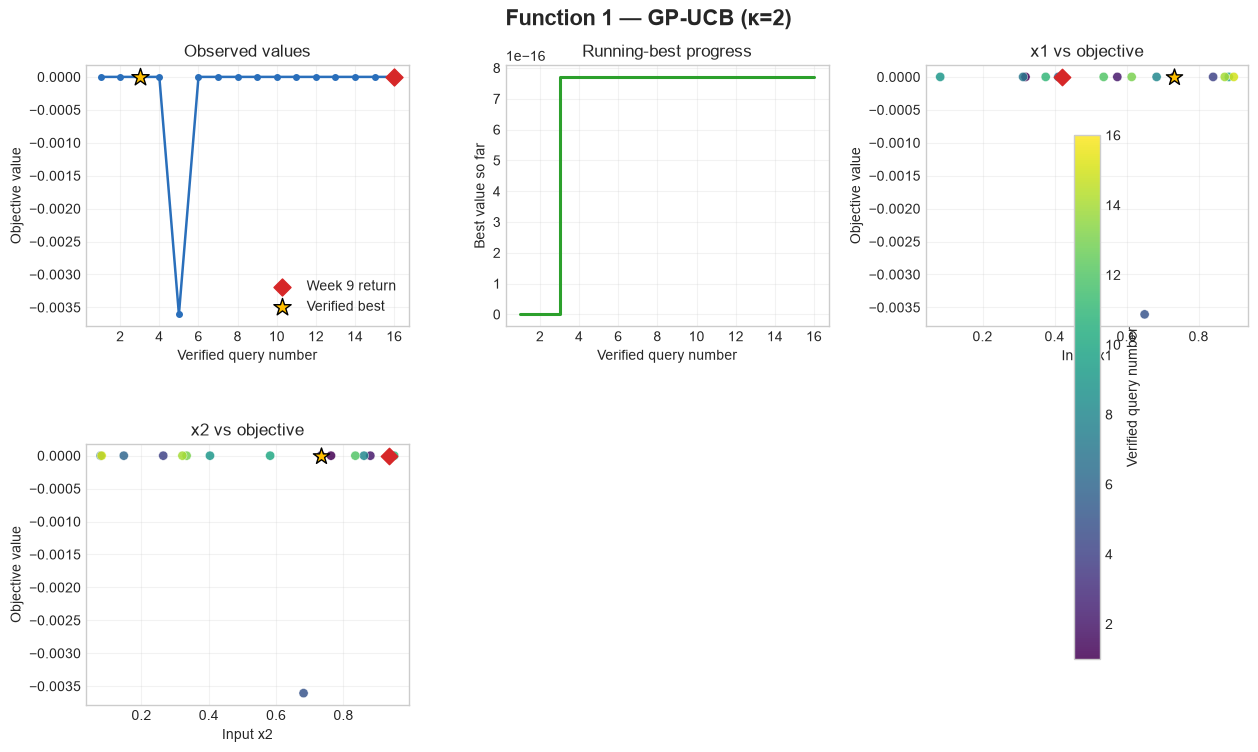

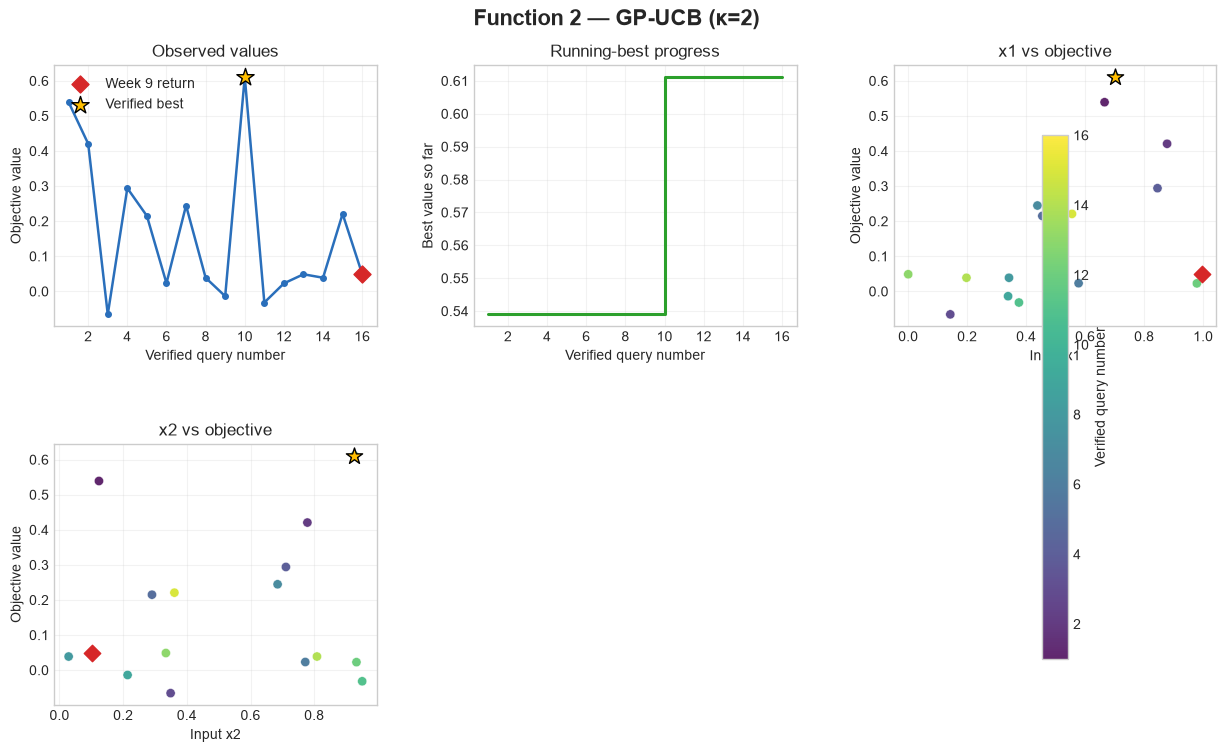

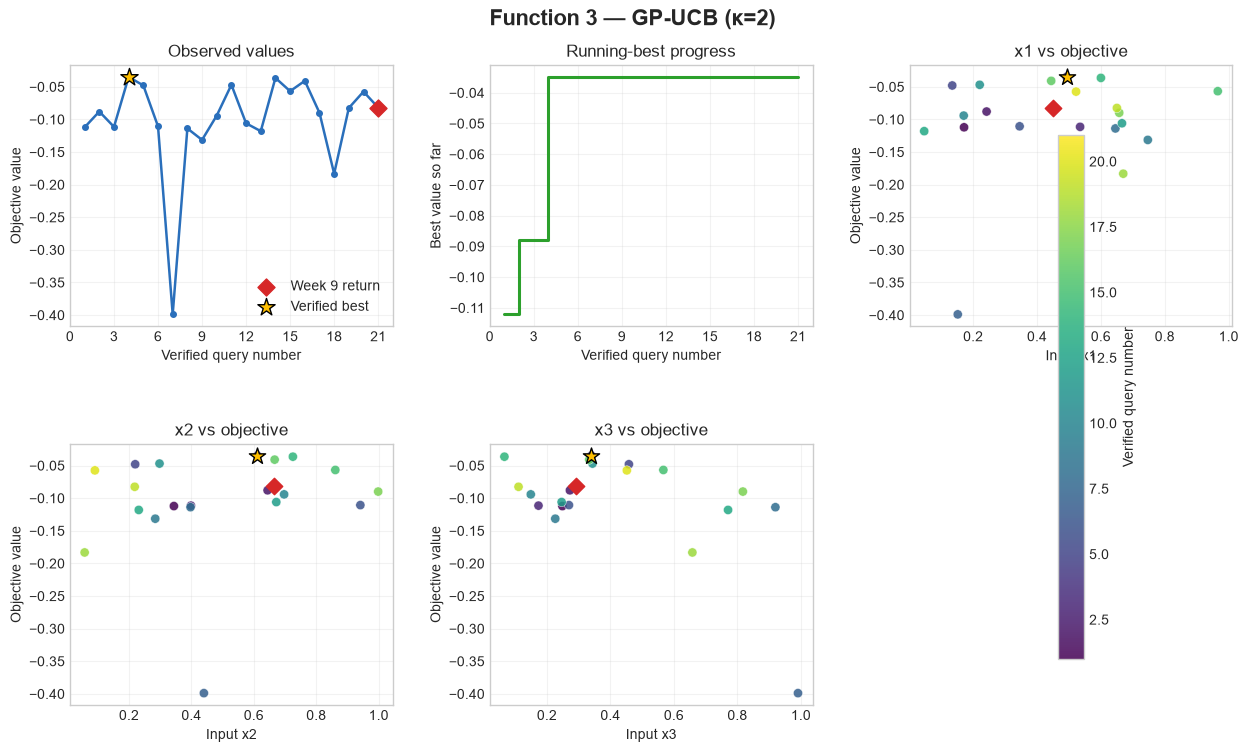

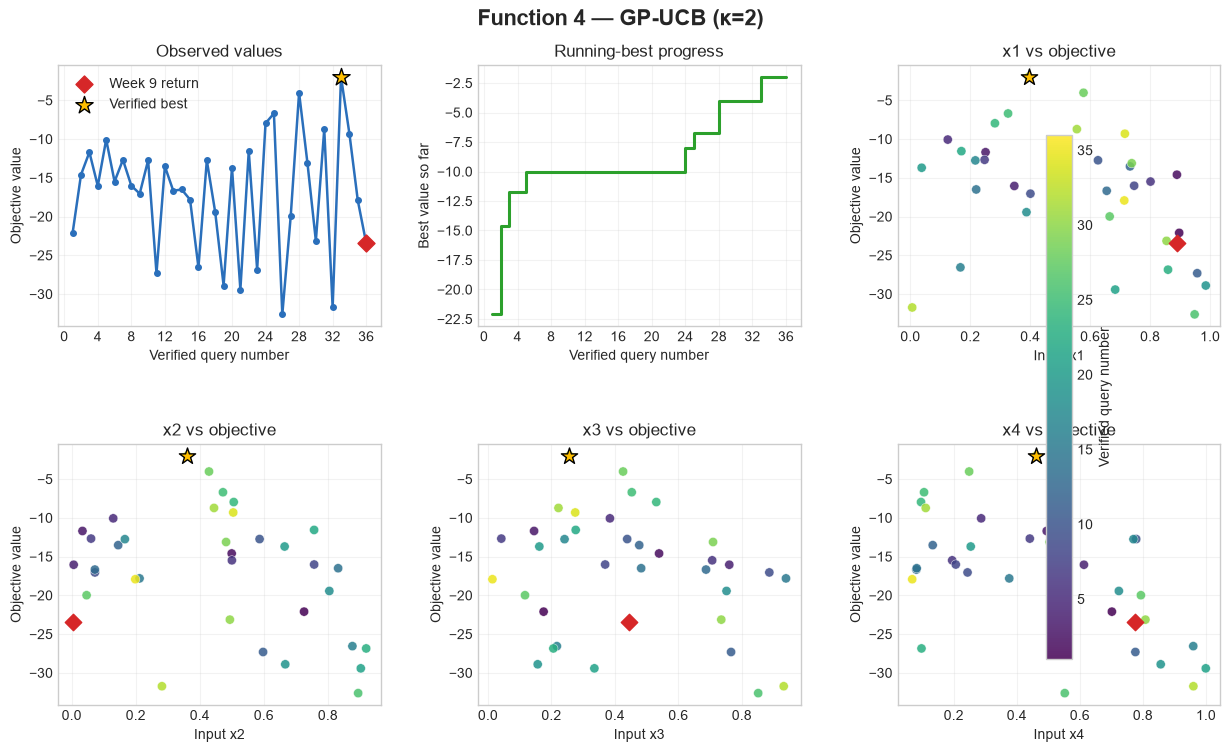

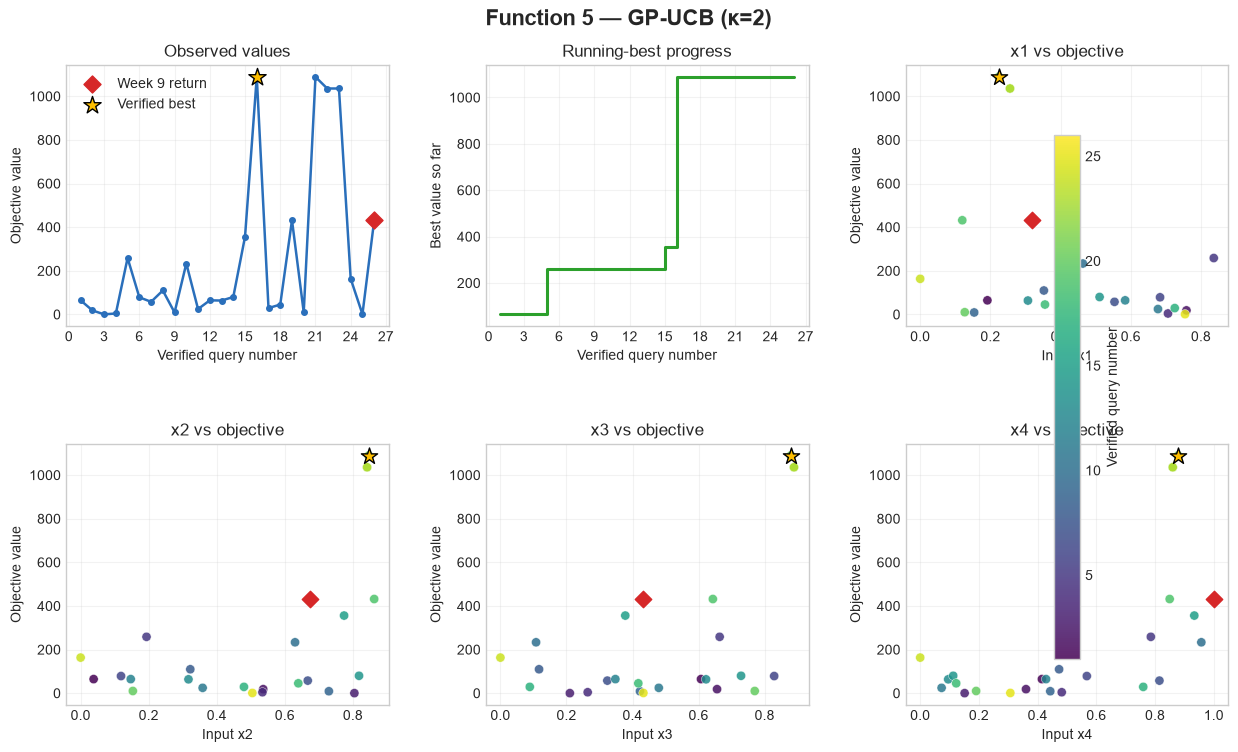

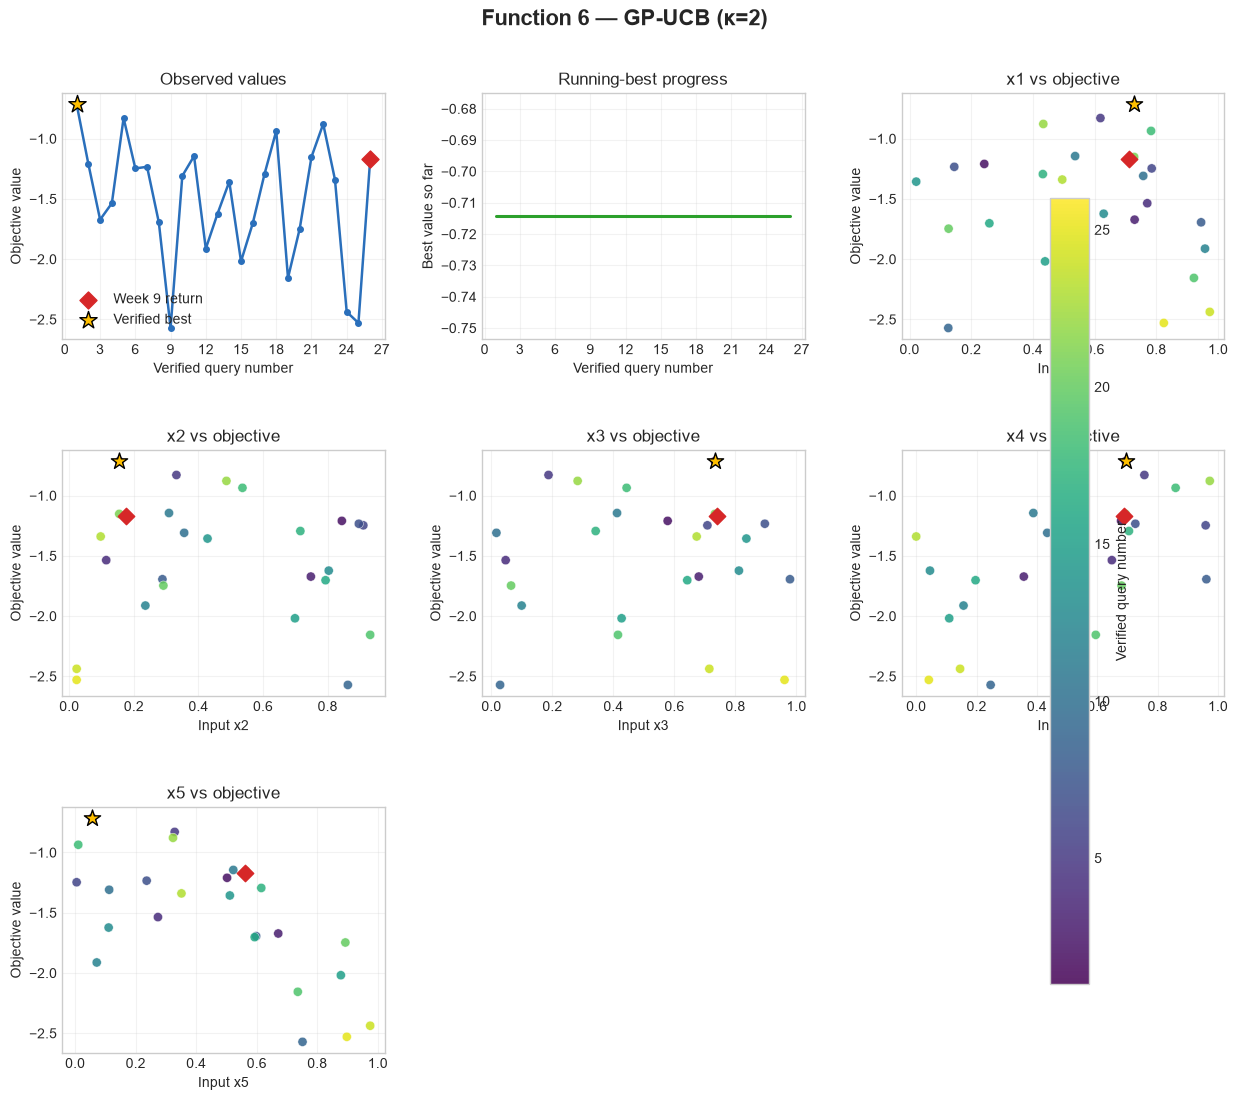

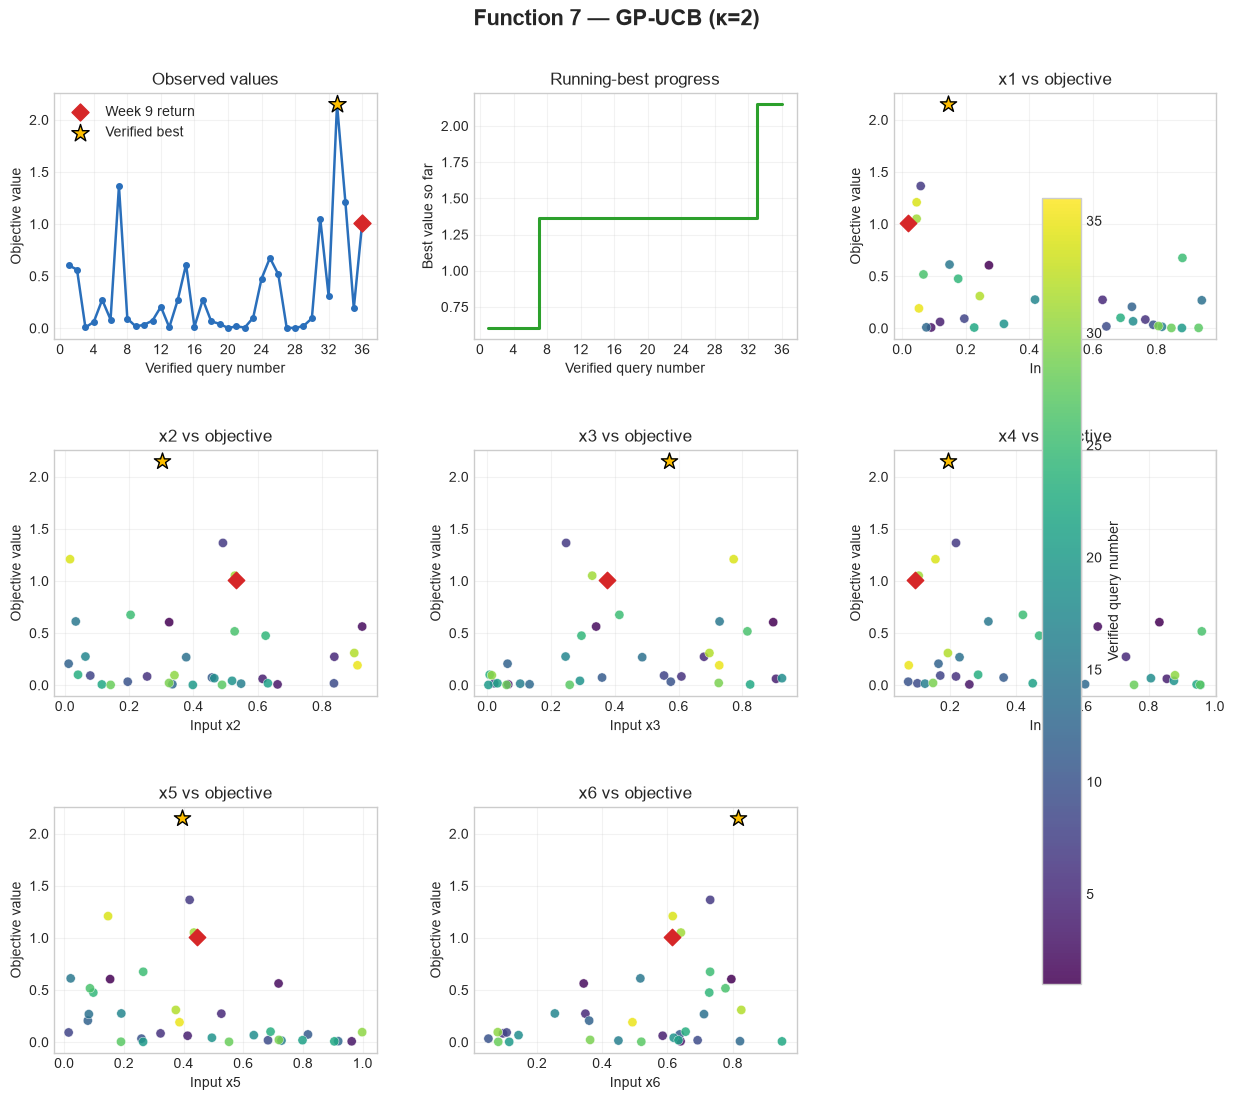

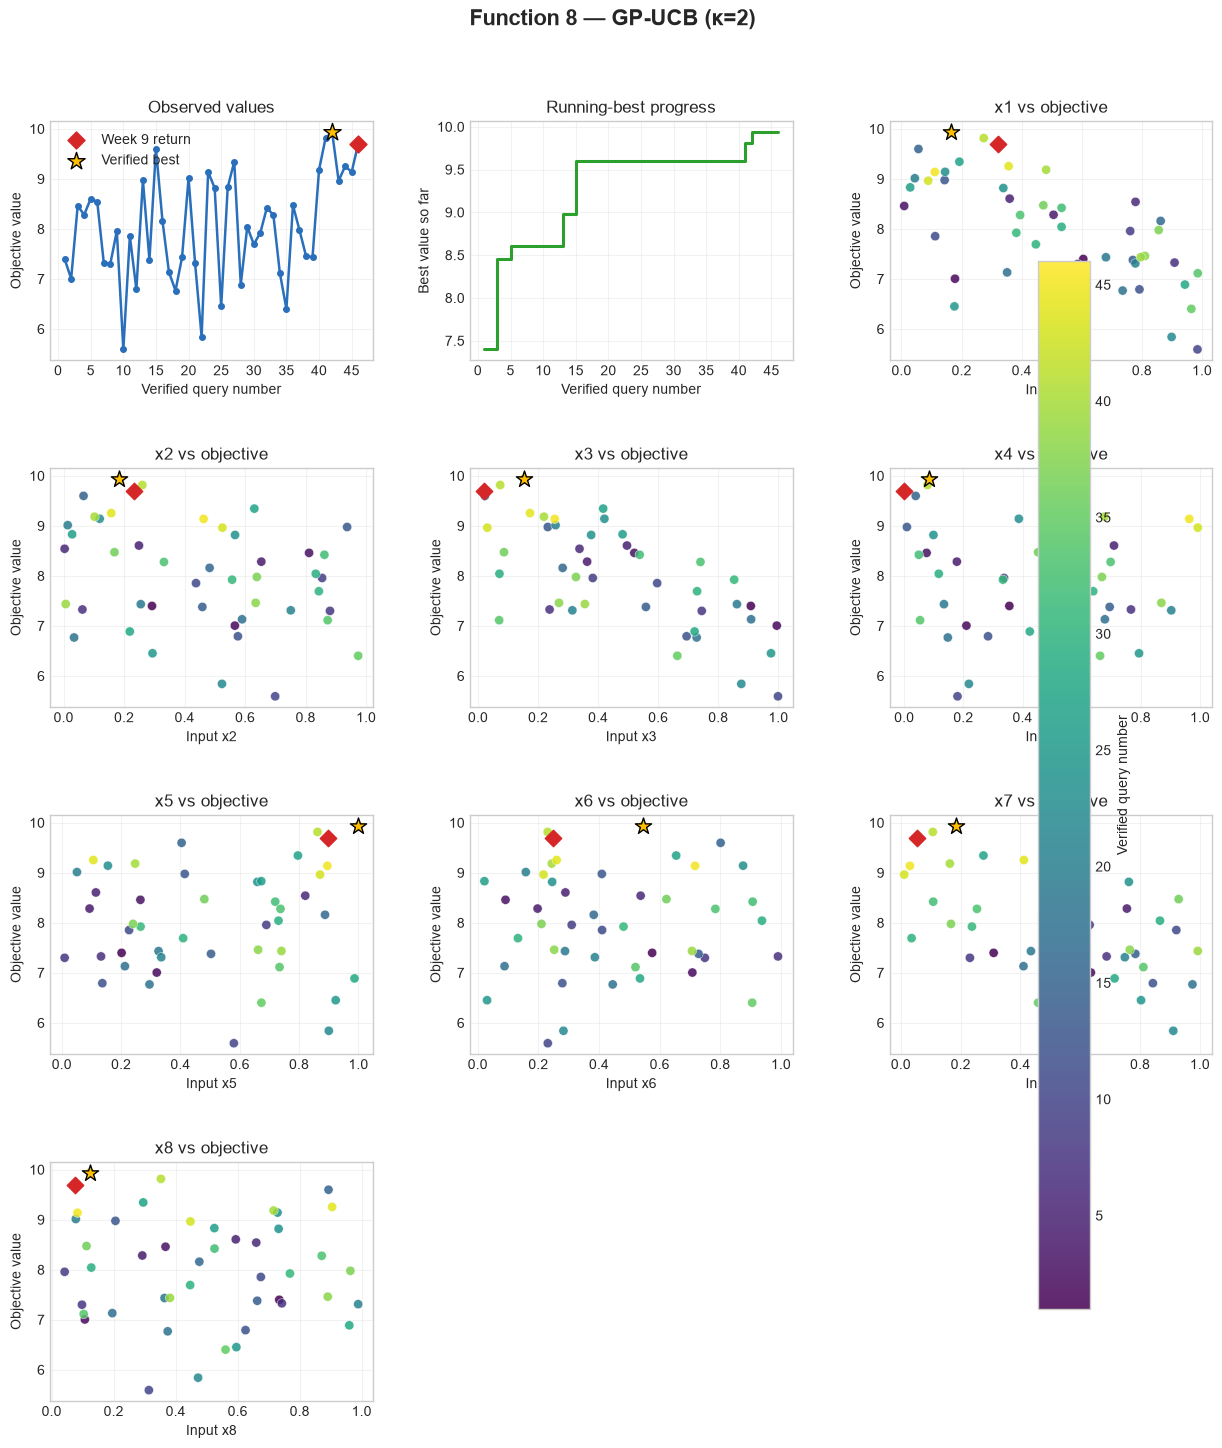

Rendered 8 function diagnostic figures.


In [7]:
def plot_function(fn):
    X,y=load_verified(fn); q=np.arange(1,len(y)+1); best=int(np.argmax(y)); panels=X.shape[1]+2; cols=3; rows=math.ceil(panels/cols); fig,axes=plt.subplots(rows,cols,figsize=(15,4*rows),squeeze=False); axes=axes.ravel()
    axes[0].plot(q,y,color='#2a6fbb',marker='o',lw=1.8,ms=4); axes[0].scatter(q[-1],y[-1],marker='D',color='#d62728',s=75,zorder=4,label='Week 9 return'); axes[0].scatter(q[best],y[best],marker='*',color='#ffbf00',edgecolor='black',s=170,zorder=5,label='Verified best'); axes[0].set(xlabel='Verified query number',ylabel='Objective value',title='Observed values'); axes[0].legend(); axes[0].xaxis.set_major_locator(MaxNLocator(integer=True))
    axes[1].step(q,np.maximum.accumulate(y),where='post',color='#2ca02c',lw=2.2); axes[1].set(xlabel='Verified query number',ylabel='Best value so far',title='Running-best progress'); axes[1].xaxis.set_major_locator(MaxNLocator(integer=True)); colour=None
    for col,axis in enumerate(axes[2:2+X.shape[1]]): colour=axis.scatter(X[:,col],y,c=q,cmap='viridis',s=44,alpha=.85,edgecolor='white',lw=.35); axis.scatter(X[-1,col],y[-1],marker='D',color='#d62728',s=70,zorder=4); axis.scatter(X[best,col],y[best],marker='*',color='#ffbf00',edgecolor='black',s=150,zorder=5); axis.set(xlabel=f'Input x{col+1}',ylabel='Objective value',title=f'x{col+1} vs objective')
    for axis in axes[panels:]: axis.set_visible(False)
    for axis in axes[:panels]: axis.grid(True,alpha=.25)
    fig.colorbar(colour,ax=axes[2:2+X.shape[1]].tolist(),label='Verified query number',shrink=.85); fig.suptitle(f'Function {fn} — GP-UCB (κ=2)',fontsize=16,fontweight='bold'); fig.subplots_adjust(top=.91,hspace=.45,wspace=.30); return fig
figures=[plot_function(i) for i in FUNCTIONS]; plt.show(); print(f'Rendered {len(figures)} function diagnostic figures.')

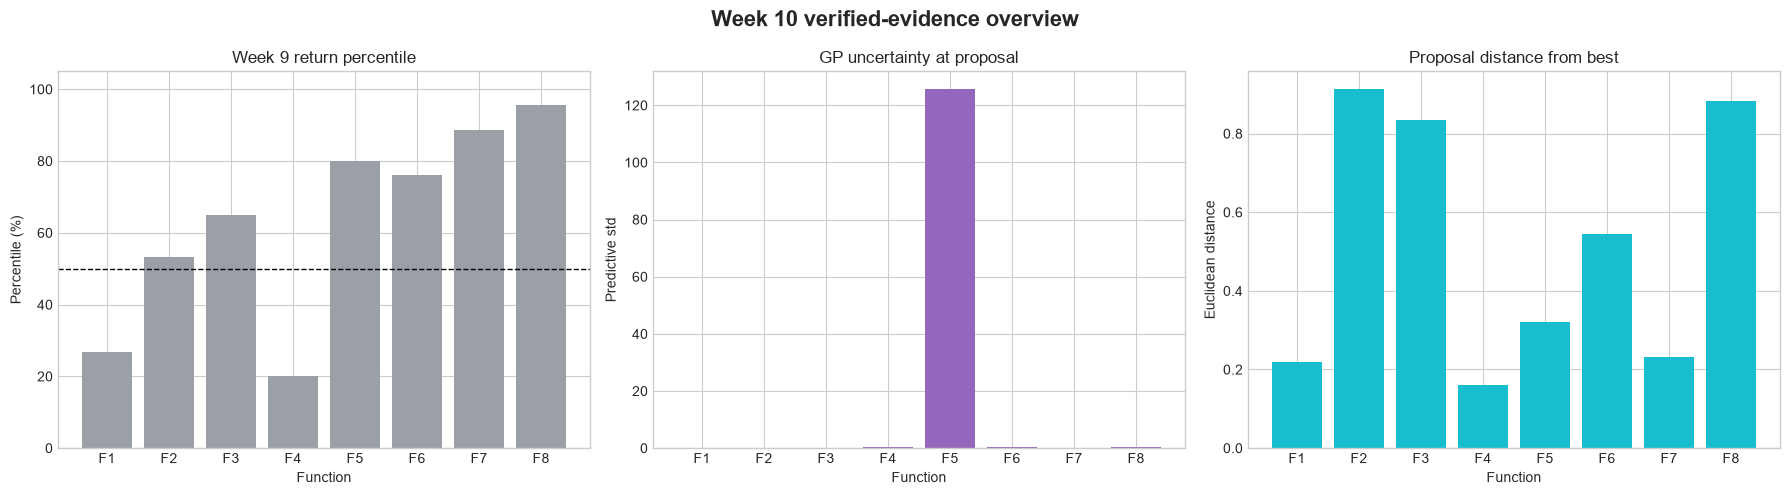

In [8]:
fig,axes=plt.subplots(1,3,figsize=(18,5)); colours=np.where(performance['Week 9 improvement']>0,'#2ca02c','#9aa0a6')
axes[0].bar(performance['Function'],performance['Week 9 percentile'],color=colours); axes[0].axhline(50,color='black',ls='--',lw=1); axes[0].set(title='Week 9 return percentile',xlabel='Function',ylabel='Percentile (%)',ylim=(0,105))
axes[1].bar(proposal_summary['Function'],proposal_summary['Predictive std'],color='#9467bd'); axes[1].set(title='GP uncertainty at proposal',xlabel='Function',ylabel='Predictive std')
axes[2].bar(proposal_summary['Function'],proposal_summary['Distance from best'],color='#17becf'); axes[2].set(title='Proposal distance from best',xlabel='Function',ylabel='Euclidean distance')
fig.suptitle('Week 10 verified-evidence overview',fontsize=16,fontweight='bold'); fig.tight_layout(); plt.show()

## Reproducible checks

In [9]:
expected={1:16,2:16,3:21,4:36,5:26,6:26,7:36,8:46}
for fn in FUNCTIONS:
    X,y=load_verified(fn); s=summarize(fn); q=week10_queries[fn]
    assert X.shape==(expected[fn],DIMS[fn]) and y.shape==(expected[fn],) and np.allclose(X[-1],W9Q[fn]) and np.isclose(y[-1],W9Y[fn])
    assert s['Best query']==int(np.argmax(y))+1 and s['Week 9 improvement']>=0
    assert q.shape==(DIMS[fn],) and np.all((q>=0)&(q<=1)) and not np.any(np.all(np.isclose(X,q,rtol=0,atol=5e-7),axis=1))
assert sum(expected.values())==223 and len(performance)==len(proposal_summary)==len(week10_queries)==8
assert performance['Provenance'].str.contains('exact Weeks 1–4, 6, and 9').all()
assert performance['Evidence gaps'].eq('Week 5 and Week 7 returns unavailable').all()
print('All Week 10 verified-data, provenance, performance, GP-UCB proposal, and plotting checks passed.')

All Week 10 verified-data, provenance, performance, GP-UCB proposal, and plotting checks passed.
